In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)
n_samples = 6000
d = 10

# Linear model
X = np.random.uniform(-1, 1, (n_samples, d))
# log-risk function
f_x = X[:, 0] + 2*X[:, 1]

lambda_0 = 1.0
U = np.random.uniform(0, 1, n_samples)
# survival times: T = - log(U) / (lambda_0 * exp(f(x)))
T = -np.log(U) / (lambda_0 * np.exp(f_x))

# censoring 50% similar to paper
C = np.random.exponential(scale=np.mean(T), size=n_samples)

time = np.minimum(T, C)  # choose minimum
event = (T <= C).astype(int)

In [3]:
# quadratic non-linear model
alpha = 3.0 # Controls the steepness of the "U" shape
X_nl_quad = np.random.uniform(-1, 1, (n_samples, d))

# f(x) = alpha * (x0^2 + x1^2)
# Risk is lowest at (0,0) and highest at the corners/edges
f_x_nl_quad = alpha * (X_nl_quad[:, 0]**2 + X_nl_quad[:, 1]**2)

U_quad = np.random.uniform(0, 1, n_samples)

# survival times: T = - log(U) / (lambda_0 * exp(f(x)))
T_nl_quad = -np.log(U_quad) / (lambda_0 * np.exp(f_x_nl_quad))

# censoring ~50%
C_nl_quad = np.random.exponential(scale=np.mean(T_nl_quad), size=n_samples)

time_nl_quad = np.minimum(T_nl_quad, C_nl_quad)
event_nl_quad = (T_nl_quad <= C_nl_quad).astype(int)

In [ ]:
# grid for surface plot
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X0, X1 = np.meshgrid(x, y)

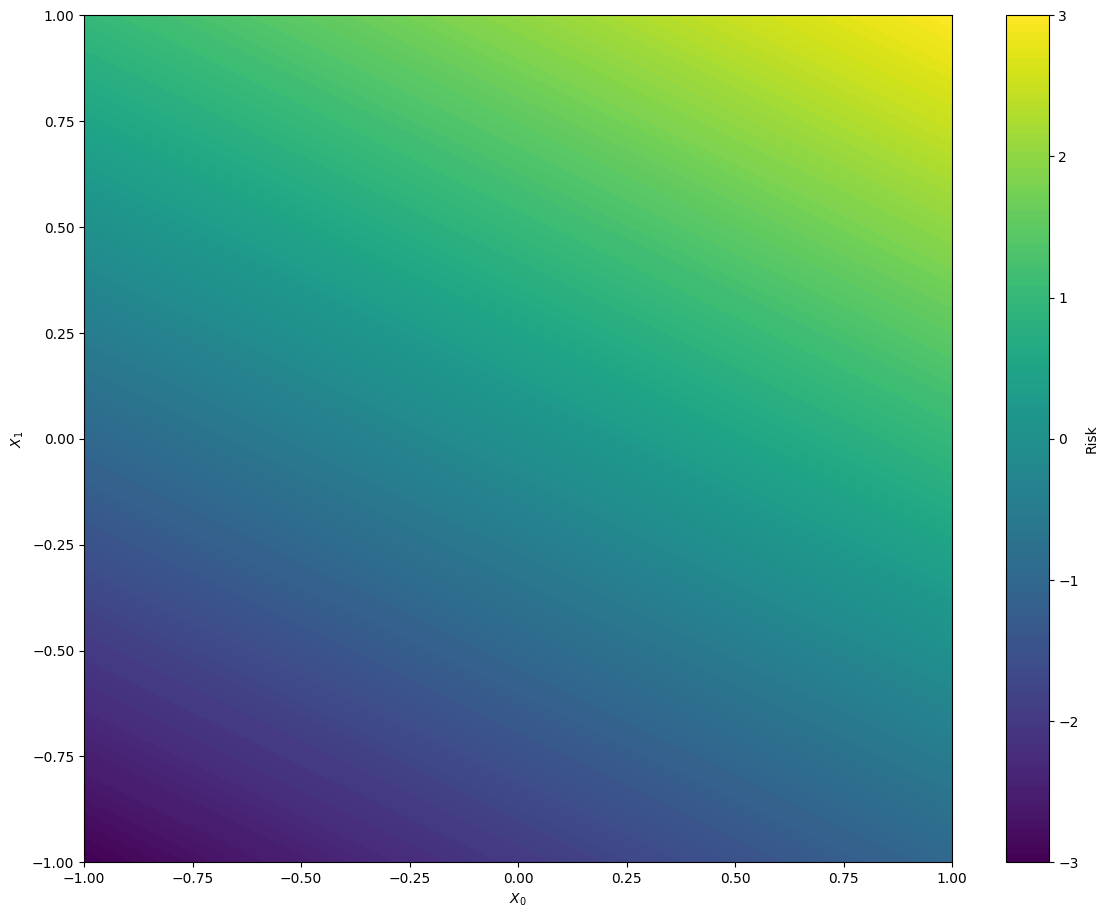

In [27]:
# linear plot
plt.figure(figsize=(14, 11))
plt.contourf(X0, X1, X0 + 2*X1, levels=100, cmap='viridis')
plt.colorbar(label='Risk', ticks=[-3, -2, -1, 0, 1, 2, 3])
plt.xlabel(r'$X_0$')
plt.ylabel(r'$X_1$')
plt.show()

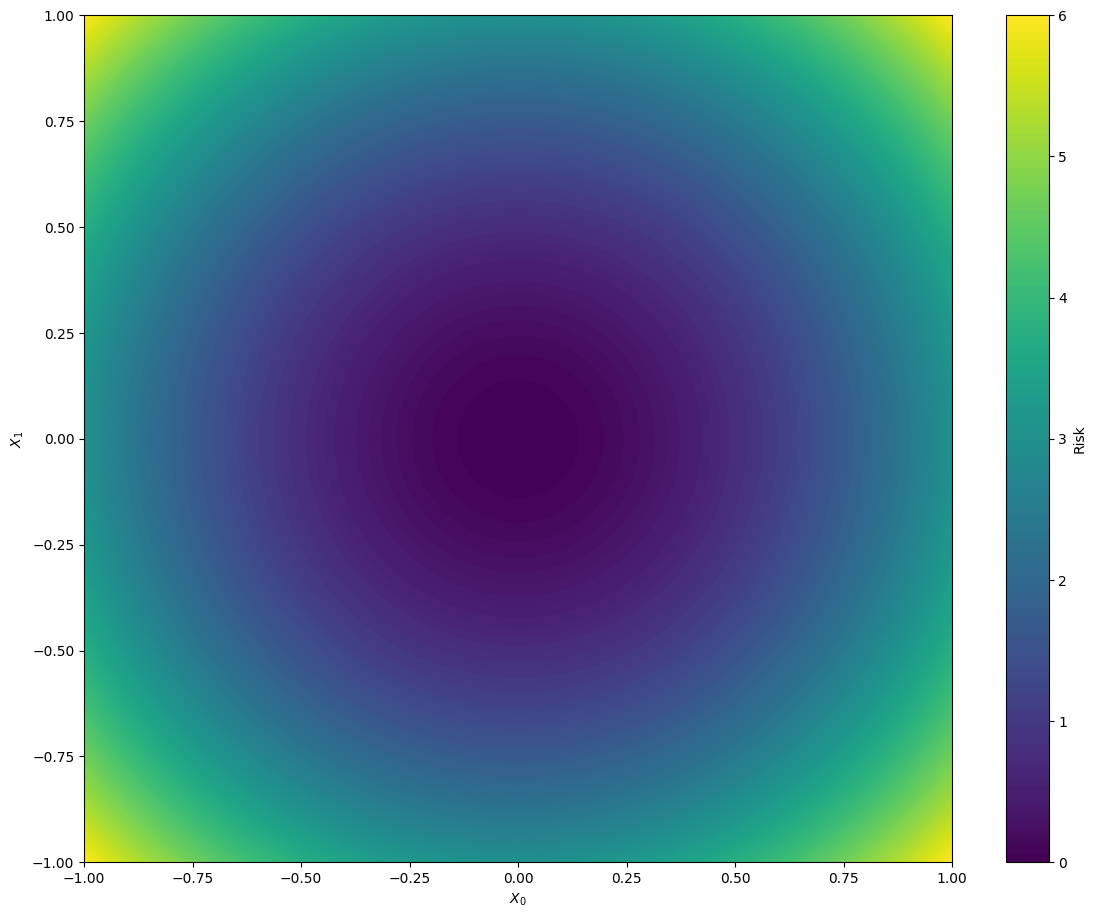

In [26]:
# quadratic plot
plt.figure(figsize=(14, 11))
plt.contourf(X0, X1, alpha * (X0**2 + X1**2), levels=100, cmap='viridis')
plt.colorbar(label='Risk', ticks=[0, 1, 2, 3, 4, 5, 6])
plt.xlabel(r'$X_0$')
plt.ylabel(r'$X_1$')
plt.show()